In [82]:
import torch
from utils import solve_riccati
import numpy as np
from network import PhiNetwork, ScoreNetwork
from utils import batched_jacobian
import matplotlib.pyplot as plt

In [83]:
phi_net = ScoreNetwork(input_dim=2+1, out_dim=2, hidden_dim=64, num_blocks=4)
phi_net.load_state_dict(torch.load('network/phi_network_diff_bsde_timesteps50_kf20_4gaussian_asymmetric_T0.4_lf33_v2.pth'))

/var/folders/pd/hp6m3j2j5v9bd6w64h7wl3rm0000gn/T/ipykernel_28606/2826145627.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  phi_net.load_state_dict(torch.load('network/p

<All keys matched successfully>

In [84]:
T = 0.4  # End time
n = 2    # Dimension of state space
m = 2    # Dimension of Brownian motion
N = 1000 # Number of training samples
dt = 0.008
steps = int(T/dt)   
noise_level = 2

In [85]:
score_nn = ScoreNetwork(input_dim=n+1, out_dim=n, hidden_dim=64, num_blocks=4)
score_nn.load_state_dict(torch.load(f'network/2dim_4gaussian_score_network_timesteps{steps}_a-2.0_s2.0_asymmetric.pth'))

/var/folders/pd/hp6m3j2j5v9bd6w64h7wl3rm0000gn/T/ipykernel_28606/3538587331.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  score_nn.load_state_dict(torch.load(f'network

<All keys matched successfully>

In [86]:
time_grid = torch.arange(0, steps+1) * dt

In [87]:
def f(x, t):
    ##TODO: maybe change t to T-t##
    """
    Drift function of X_t for a nonlinear system.
    Args:
        x (torch.Tensor): State vector. Shape (N, n)
        t (torch.Tensor): torch.tensor of shape (1,): Current time
    Returns:
        torch.Tensor: Drift vector. Shape (N, n)
    """
    a = 2
    df = a * x + noise_level**2 * score_nn(x, (T - t).repeat(x.shape[0], 1))
    return df


def g(x):
    """
    Diffusion function of X_t for a nonlinear system.
    Args:
        x (torch.Tensor): State vector. Shape (N, n)
    Returns:
        torch.Tensor: Diffusion matrix. Shape (N, n, m)
    """
    B = torch.eye(n) * noise_level
    B = B.unsqueeze(0).repeat(x.shape[0], 1, 1)
    return B

def lf(x):
    """
    Terminal cost function for a linear system.
    Args:
        x (torch.Tensor): State vector. Shape (N, n)
    Returns:
        torch.Tensor: Terminal cost. Shape (N,)
    """
    upper_center = torch.tensor([3.0, 3.0]).repeat(x.shape[0], 1)
    cost = torch.einsum('bi, bi -> b', x - upper_center, x - upper_center) * 0.5
    return cost

def special_f(x, t=None):
    """
    Drift function of X_t for a nonlinear system.
    Args:
        x (torch.Tensor): State vector. Shape (N, n)
    Returns:
        torch.Tensor: Drift vector. Shape (N, n)
    """
    a = 2
    return -a * x

def partial_lf(x):
    """
    Gradient of the terminal cost function for a linear system.
    Args:
        x (torch.Tensor): State vector. Shape (N, n)
    Returns:
        torch.Tensor: Gradient of the terminal cost. Shape (N, n)
    """
    # Q_f = torch.tensor([[1.0, 0.0], [0.0, 1.0]])
    # return x @ Q_f
    upper_center = torch.tensor([3.0, 3.0]).repeat(x.shape[0], 1)
    return x - upper_center

def H_x(x, y, z, t):
    ##TODO: maybe change t to T-t##
    """
    Partial derivative of Hamiltonian respect to the x for Y_t in the BSDE.
    Args:
        x (torch.Tensor): State vector. Shape (N, n)
        y (torch.Tensor): Costate vector. Shape (N, n)
        z (torch.Tensor): Second order term in BSDE. Shape (N, n, m)
        t (torch.Tensor): Current time. Shape (1,)
    Returns:
        # torch.Tensor: Drift vector. Shape (N, n)
        cost_term (torch.Tensor): Running cost term. Shape (N, n)
        lag_term_mat (torch.Tensor): Lagrange term y^T f_x. Shape (N, n, n)
        trace_term (torch.Tensor): Trace term Tr(z g_x). Shape (N, n)
    """
    # running cost term
    # zero for this example
    cost_term = torch.zeros_like(x)  # shape (N, n)

    # lagrange term y^T f_x
    a = 2
    lag_term_mat = torch.ones((x.shape[0], n, n)) * a  # shape (N, n, n)
    x.requires_grad_(True)
    score = score_nn(x, (T - t).repeat(x.shape[0], 1))  # shape (N, n)
    grad_score = batched_jacobian(score, x).detach()  # shape (N, n, n)
    lag_term_mat = lag_term_mat + noise_level**2 * grad_score  # shape (N, n, n)

    # trace term Tr(z g_x)
    trace_term = torch.zeros_like(x)  # shape (N, n)
    # return cost_term + lag_term + trace_term
    return cost_term, lag_term_mat, trace_term

In [88]:
from utils import rollout, noise, time_reversal_bsde, train_phi_network

In [89]:
theta0 = torch.randn((N, n))

theta_auto = theta0.clone().detach().requires_grad_(True)
theta_phi  = theta0.clone().detach().requires_grad_(True)  # requires_grad can stay True; we won't call backward()

opt_auto = torch.optim.Adam([theta_auto], lr=1e-2)
opt_phi  = torch.optim.Adam([theta_phi],  lr=1e-2)

loss_hist_auto = []
loss_hist_phi  = []
theta_hist_auto = []
theta_hist_phi  = []
theta_hist_auto.append(theta_auto.detach().clone())
theta_hist_phi.append(theta_phi.detach().clone())
for i in range(10000):
    W_f = torch.randn(steps + 1, N, m) * torch.sqrt(torch.tensor(dt))
    # ======== Method A: autograd ========
    opt_auto.zero_grad(set_to_none=True)

    # compute loss (keep exactly same code path)
    xT_auto = rollout(f, g, T, dt, theta_auto, W_f)[-1]
    loss_auto = lf(xT_auto).sum(dim=0)
    mean_auto = theta_auto.mean(dim=0)  # shape (1, n)
    temp_auto = theta_auto - mean_auto.repeat(theta_auto.shape[0], 1)  # shape (N, n)
    var_auto = ((temp_auto.T @ temp_auto) / (N - 1))  # shape (n, n)
    var_auto_inv = torch.linalg.pinv(var_auto + 1e-6 * torch.eye(n))  # shape (n, n)
    kl_auto = 0.5 * (torch.trace(var_auto) + mean_auto @ mean_auto - n - torch.logdet(var_auto + 1e-6 * torch.eye(n)))
    loss_auto = loss_auto + kl_auto
    loss_auto.backward()
    opt_auto.step()

    # ======== Method B: custom phi gradient ========
    opt_phi.zero_grad(set_to_none=True)

    # compute loss for logging only (optional but useful)
    # If rollout is expensive and you only care about update, you can skip this forward.
    # with torch.no_grad():
    #     xT_phi = rollout(f, g, T, dt, theta_phi, W_f)[-1]
    #     loss_phi = lf(xT_phi).sum(dim=0)

    # apply your gradient estimator
    # IMPORTANT: optimizer expects theta_phi.grad to be a tensor on same device/dtype
    ## Autograd for kl divergence term 
    with torch.no_grad():
        ghat_lf = phi_net(theta_phi, torch.tensor(0.0).repeat(theta_phi.shape[0], 1))  # shape (N, n)
        mean_theta = theta_phi.mean(dim=0)  # shape (1, n)
        temp = theta_phi - mean_theta.repeat(theta_phi.shape[0], 1)  # shape (N, n)
        var_theta = ((temp.T @ temp) / (N - 1))  # shape (n, n)
        var_theta_inv = torch.linalg.pinv(var_theta + 1e-6 * torch.eye(n))  # shape (n, n)
        ghat_kl = (-var_theta_inv @ temp.T  + theta_phi.T).T  # shape (N, n)
        # ghat_kl = ((var_theta_inv - torch.eye(n)) @ temp.T) + mean_theta.repeat(N, 1).T # shape (n, N)
        ghat = ghat_lf + ghat_kl  # shape (N, n)
        theta_phi.grad = ghat.detach() 
        if i % max(1, 500) == 0:
            print(f"iteration {i:4d} | phi_grad for 1st sample: {ghat_lf[0].detach().numpy()} | kl_grad for 1st sample: {ghat_kl[0].detach().numpy()} | total grad for 1st sample: {ghat[0].detach().numpy()}")
    opt_phi.step()
    
    # ---- log ----
    loss_hist_auto.append(loss_auto.detach().item() if loss_auto.numel()==1 else loss_auto.detach().sum().item())
    # loss_hist_phi.append(loss_phi.detach().item()  if loss_phi.numel()==1  else loss_phi.detach().sum().item())

    # theta_hist_auto.append(theta_auto.detach().clone())
    # theta_hist_phi.append(theta_phi.detach().clone())

    # optional: print occasionally
    # if i % max(1, 500) == 0:
    #     print(f"iteration {i:4d} | autograd loss {loss_hist_auto[-1]:.6g} | phi loss {loss_hist_phi[-1]:.6g}")
    if i % max(1, 500) == 0:
        print(f"iteration {i:4d} | autograd loss {loss_hist_auto[-1]:.6g}")

    # if (i % 3000 == 0) & (i > 0):
    #     print(f"\n--- Retraining phi_net at iteration {i} ---")
    #     # retrain phi_net on current theta_phi (optional, can be expensive)
    #     # You can skip this step if you want to keep phi_net fixed, but retraining can help it adapt to the new theta distribution.
    #     # optimizer_phi_net = torch.optim.Adam(phi_net.parameters(), lr=1e-3)
    #     # scheduler_phi_net = torch.optim.lr_scheduler.StepLR(optimizer_phi_net, step_size=1000, gamma=0.5)
    #     optimizer_phi_net = torch.optim.AdamW(phi_net.parameters(), lr=1e-5, weight_decay=1e-4)
    #     scheduler_phi_net = torch.optim.lr_scheduler.StepLR(optimizer_phi_net, step_size=2000, gamma=0.9)
    #     # Generate new training data for phi_net based on current theta_phi
    #     W_train = torch.randn(steps + 1, N, m) * torch.sqrt(torch.tensor(dt))
    #     X_train = rollout(special_f, g, T, dt, theta_phi.clone().detach(), W_train).detach().flip(dims=[0])  # shape (steps+1, N, n)
    #     Y_T_train = partial_lf(theta_phi.clone().detach())  # shape (N, n)
    #     Y_train = time_reversal_bsde(H_x, g, phi_net, T, dt, Y_T_train, W_train, [score_nn], X_train, nn_num=1)
    #     loss_phi_net = train_phi_network(phi_net, X_train, Y_train, time_grid, optimizer_phi_net, scheduler_phi_net, batch_size=64, iterations=8000)

# ---- final report ----
# print("\nFinal:")
# print(f"autograd: loss={loss_hist_auto[-1]:.6g}")
# print(f"phi     : loss={loss_hist_phi[-1]:.6g}")

# ---- plot ----
# plt.figure()
# # plt.plot(loss_hist_auto, label="autograd")
# plt.plot(loss_hist_phi,  label="phi(theta) grad")
# plt.yscale("log")  # often helpful; remove if you prefer linear
# plt.xlabel("step")
# plt.ylabel("loss")
# plt.title("Loss convergence comparison")
# plt.legend()
# plt.grid(True, which="both", linestyle="--", linewidth=0.5)
# plt.show()

iteration    0 | phi_grad for 1st sample: [-0.64029074 -0.74156797] | kl_grad for 1st sample: [0.00760767 0.00184517] | total grad for 1st sample: [-0.63268304 -0.7397228 ]
iteration    0 | autograd loss 11990.1
iteration  500 | phi_grad for 1st sample: [-0.49393353 -0.6199299 ] | kl_grad for 1st sample: [0.49714437 0.6252678 ] | total grad for 1st sample: [0.00321084 0.00533789]
iteration  500 | autograd loss 6669.5
iteration 1000 | phi_grad for 1st sample: [-0.505405  -0.6495058] | kl_grad for 1st sample: [0.5045681  0.65041864] | total grad for 1st sample: [-0.00083691  0.00091285]
iteration 1000 | autograd loss 6243.9
iteration 1500 | phi_grad for 1st sample: [-0.49413046 -0.6544357 ] | kl_grad for 1st sample: [0.49383858 0.65465724] | total grad for 1st sample: [-0.00029188  0.00022155]
iteration 1500 | autograd loss 6007.19
iteration 2000 | phi_grad for 1st sample: [-0.4941736  -0.65592736] | kl_grad for 1st sample: [0.4943421 0.6558302] | total grad for 1st sample: [ 1.6850233e-

Text(0.5, 1.0, 'Optimal theta comparison')

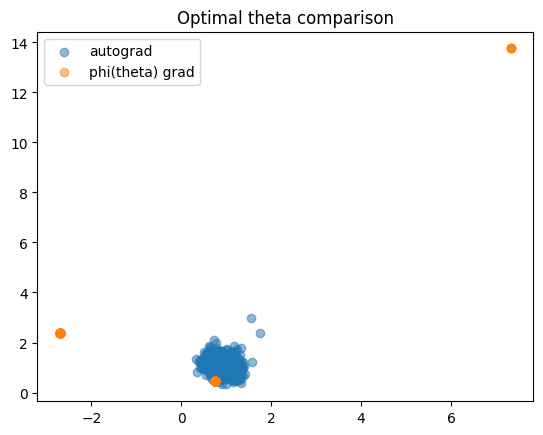

In [90]:
## plot of optimal theta
plt.figure()
plt.scatter(theta_auto.detach().numpy()[:,0], theta_auto.detach().numpy()[:,1], label="autograd", alpha=0.5)
plt.scatter(theta_phi.detach().numpy()[:,0], theta_phi.detach().numpy()[:,1], label="phi(theta) grad", alpha=0.5)
# plt.xscale("log")
# plt.yscale("log")   
plt.legend()
plt.title("Optimal theta comparison")

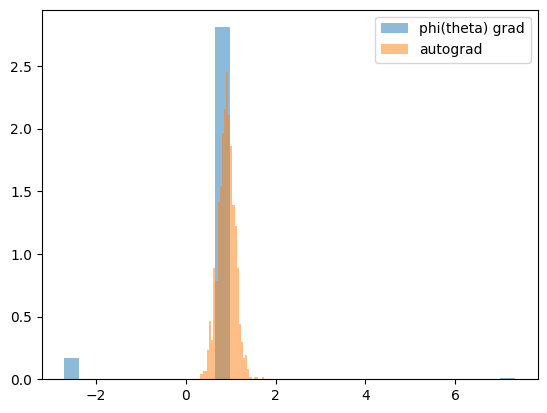

In [91]:
plt.figure()
plt.hist(theta_phi.detach().numpy()[:,0], bins=30, alpha=0.5, label='phi(theta) grad', density=True)
plt.hist(theta_auto.detach().numpy()[:,0], bins=30, alpha=0.5, label='autograd', density=True)
plt.legend()
plt.show()

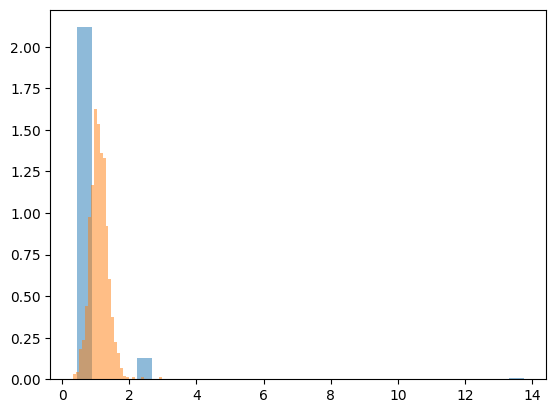

In [92]:
plt.figure()
plt.hist(theta_phi.detach().numpy()[:,1], bins=30, alpha=0.5, label='phi(theta) grad', density=True)
plt.hist(theta_auto.detach().numpy()[:,1], bins=30, alpha=0.5, label='autograd', density=True)
plt.show()

In [93]:
theta_phi.detach().mean(dim=0), theta_auto.detach().mean(dim=0)

(tensor([0.5805, 0.6150]), tensor([0.9091, 1.0955]))

In [94]:
theta_phi.detach().std(dim=0), theta_auto.detach().std(dim=0)

(tensor([0.9073, 0.9435]), tensor([0.1858, 0.2667]))

In [95]:
randindex = np.random.randint(0, theta_phi.shape[0], size=50) # generate 50 random index
theta_phi.detach()[randindex,0]

tensor([0.7509, 0.7509, 0.7509, 0.7509, 0.7509, 0.7509, 0.7509, 0.7509, 0.7508,
        0.7509, 0.7509, 0.7509, 0.7508, 0.7508, 0.7509, 0.7509, 0.7508, 0.7509,
        0.7509, 0.7509, 0.7509, 0.7509, 0.7509, 0.7509, 0.7509, 0.7509, 0.7509,
        0.7509, 0.7509, 0.7509, 0.7508, 0.7509, 0.7509, 0.7509, 0.7509, 0.7509,
        0.7508, 0.7509, 0.7509, 0.7509, 0.7508, 0.7509, 0.7509, 0.7509, 0.7509,
        0.7509, 0.7509, 0.7509, 0.7509, 0.7509])

In [96]:
# X_test = theta_phi.detach().mean(dim=0).repeat(N, 1) + 10

In [97]:
final_traj_phi = rollout(f, g, T, dt, theta_phi, W_f)
compare_traj = rollout(f, g, T, dt, theta_auto, W_f)

In [98]:
# test_traj = rollout(f, g, T, dt, X_test, W_f)

In [99]:
final_traj_phi.shape

torch.Size([51, 1000, 2])

Text(0.5, 1.0, 'Optimal theta comparison')

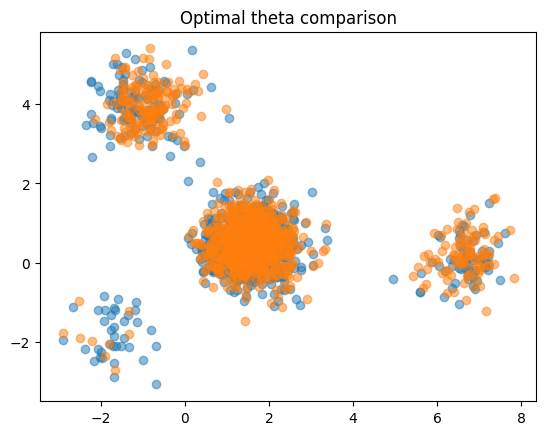

In [100]:
plt.figure()
# plt.scatter(theta_auto.detach().numpy()[:,0], theta_auto.detach().numpy()[:,1], label="autograd", alpha=0.5)
plt.scatter(final_traj_phi.detach().numpy()[-1,:,0], final_traj_phi.detach().numpy()[-1,:,1], label="phi(theta) grad", alpha=0.5)
plt.scatter(compare_traj.detach().numpy()[-1,:,0], compare_traj.detach().numpy()[-1,:,1], label="autograd traj", alpha=0.5)
# plt.scatter(test_traj.detach().numpy()[-1,:,0], test_traj.detach().numpy()[-1,:,1], label="test traj", alpha=0.5)
# plt.legend()
plt.title("Optimal theta comparison")

In [101]:
final_traj_phi.detach()[-1,:,:].mean(dim=0)

tensor([1.4659, 0.7436])

In [102]:
final_traj_phi.detach()[-1,:,:].std(dim=0)

tensor([1.7635, 1.3127])

In [103]:
from utils import generate_initial_data

In [104]:
# INITIAL_DIST = 'Bimodal'  # 'Gaussian' or 'Bimodal'
# shift = 3.0
# m_0 = torch.tensor([0.0])  # Mean of initial distribution
# sigma_0 = torch.eye(n) * 1  # Covariance of initial distribution
# X_0 = generate_initial_data(INITIAL_DIST, m_0, sigma_0, N, shift)

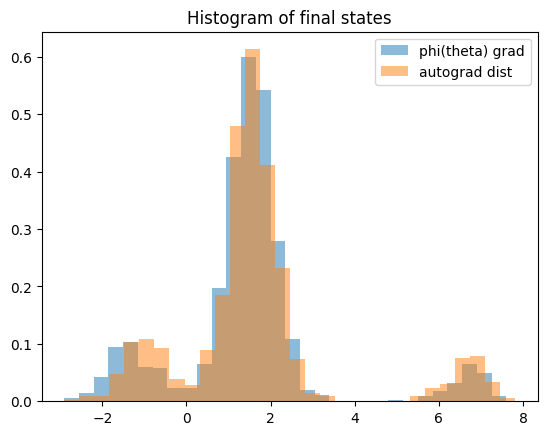

In [105]:
plt.figure()
plt.hist(final_traj_phi[-1,:,0].detach().numpy(), bins=30, alpha=0.5, label='phi(theta) grad', density=True)
plt.hist(compare_traj[-1,:,0].detach().numpy(), bins=30, alpha=0.5, label='autograd dist', density=True)
# plt.hist(final_traj_auto[-1,:,:].detach().numpy(), bins=30, alpha=0.5, label='autograd')
plt.legend()
plt.title("Histogram of final states")
plt.show()

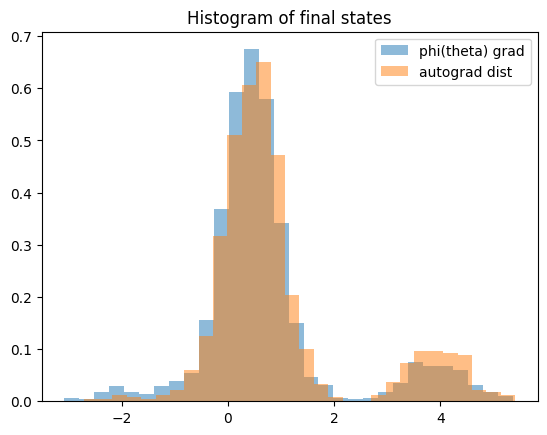

In [106]:
plt.figure()
plt.hist(final_traj_phi[-1,:,1].detach().numpy(), bins=30, alpha=0.5, label='phi(theta) grad', density=True)
plt.hist(compare_traj[-1,:,1].detach().numpy(), bins=30, alpha=0.5, label='autograd dist', density=True)
# plt.hist(final_traj_auto[-1,:,:].detach().numpy(), bins=30, alpha=0.5, label='autograd')
plt.legend()
plt.title("Histogram of final states")
plt.show()

In [107]:
test = torch.tensor([4.0, 0.0]).repeat(100, 1)

In [108]:
def gaussian_mixture_pdf(x, centers, std=0.5):
    """
    Compute pdf of equal-weight Gaussian mixture

    x: (N,d) points where pdf is evaluated
    centers: (K,d)
    std: scalar

    return: (N,) pdf values
    """
    device = x.device
    N, d = x.shape
    K = centers.shape[0]

    var = std**2

    # (N,K,d)
    diff = x.unsqueeze(1) - centers.unsqueeze(0)

    # squared norm (N,K)
    sq = (diff**2).sum(dim=2)

    # Gaussian normalization
    const = 1 / ((2*torch.pi*var)**(d/2))

    # component pdfs (N,K)
    comp = const * torch.exp(-0.5 * sq / var)

    # mixture average
    pdf = comp.mean(dim=1)

    return pdf

In [109]:
def explf(x):
    center = torch.tensor([3.0, 3.0])
    return torch.exp(-0.5 * ((x - center)**2).sum(dim=1)) # shape (N,)

In [110]:
centers = torch.tensor([
    [ 7.0,  0.0],
    [ 1.5,  0.4],
    [ -1.0,  4.0],
    [ -2.0, -2.0],
])

In [111]:
nx, ny = 1000, 1000
# create a grid of points

x = torch.linspace(-3.0, 8.0, nx)
y = torch.linspace(-3.0, 8.0, ny)

# meshgrid
X, Y = torch.meshgrid(x, y, indexing='ij')  # shapes (nx, ny)

In [112]:
xy_grid = torch.stack((X, Y), dim=2).reshape(-1, 2)  # shape (nx*ny, 2)

In [113]:
xy_grid.shape

torch.Size([1000000, 2])

In [114]:
heatmap = gaussian_mixture_pdf(xy_grid, centers, std=0.5) * explf(xy_grid)
# normalize for better visualization
heatmap = heatmap / (heatmap.sum() * (x[1] - x[0]) * (y[1] - y[0]))  # approximate integral for normalization
heatmap = heatmap.reshape(nx, ny) 

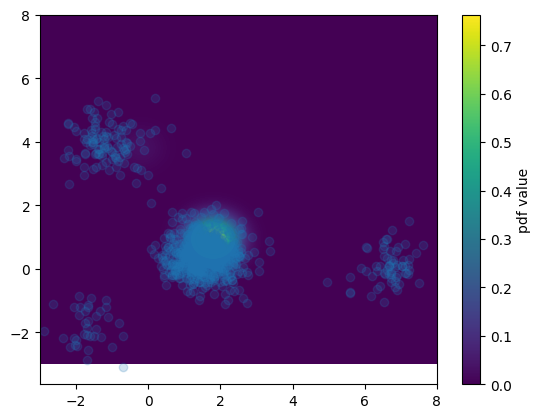

In [126]:
plt.figure()
plt.imshow(
    heatmap.T,                          # transpose for correct orientation
    extent=[-3, 8, -3, 8],
    origin='lower',
    aspect='auto',
    cmap='viridis'
)
plt.colorbar(label='pdf value')
plt.scatter(final_traj_phi.detach().numpy()[-1,:,0], final_traj_phi.detach().numpy()[-1,:,1], label="phi(theta) grad", alpha=0.2)

In [116]:
# exp_num = 1000
# loss_vec = torch.zeros((xy_grid.shape[0], 1))
# for exp_i in range(exp_num):
    
#         # generate noise
#     # W_f = torch.zeros((steps+1, theta_hist_phi_vec.shape[0], m))# forward noise
#     # for noise_step in range(steps+1):
#     #     # print(noise_step)
#     #     W_f[noise_step, :, :] = noise(dt, theta_hist_phi_vec.shape[0], m)
#     W_f = torch.randn(steps + 1, xy_grid.shape[0], m) * torch.sqrt(torch.tensor(dt))
    
#     loss_vec += lf(rollout(f, g, T, dt, xy_grid, W_f)[-1]).unsqueeze(-1).detach() # shape (N, 1)
    

#     if exp_i % 100 == 0:
#         print(f"experiment {exp_i}/{exp_num} done.")

In [117]:
# loss_vec /= exp_num  # shape (N, 1)
# loss_grid = loss_vec.reshape(nx,ny)

In [118]:
# plt.figure()
# plt.imshow(
#     loss_grid.T,                          # transpose for correct orientation
#     extent=[-1, 15, -1, 50],
#     origin='lower',
#     aspect='auto',
#     cmap='viridis'
# )
# # plt.scatter(theta_auto_final[:,0].detach().numpy(), theta_auto_final[:,1].detach().numpy(), label="AutoGrad", alpha=0.2, color='C1')
# # plt.scatter(theta_phi_final[:,0].detach().numpy(), theta_phi_final[:,1].detach().numpy(), label="BSDE", alpha=0.9, color='C0')
# plt.colorbar(label='Cost')
# # plt.xlabel(r'$\theta$')
# # plt.ylabel(r'$\dot{\theta}$')
# plt.legend()
# # plt.title('Heatmap of f(x, y)')
# plt.show()

In [119]:
# coords = torch.unravel_index(torch.argmin(loss_grid.squeeze(-1)), (100, 100))

In [120]:
# coords, x[coords[0]], y[coords[1]], loss_grid[coords]

In [121]:
# theta_test = torch.tensor([[16, 34]]).repeat(N, 1)
# final_traj_test = rollout(f, g, T, dt, theta_test, torch.randn(steps + 1, theta_test.shape[0], m) * torch.sqrt(torch.tensor(dt)))

In [122]:
# plt.figure()
# plt.scatter(final_traj_test.detach().numpy()[-1,:,0], final_traj_test.detach().numpy()[-1,:,1], label="test traj", alpha=0.5)

In [123]:
# ((final_traj_test.detach()[-1,:,:] - torch.tensor([3.0, 3.0]))**2).sum(dim=1).mean()/2

In [124]:
# ((torch.randn(N, n)*0.5 + torch.tensor([2.0, 2.0]) - torch.tensor([3.0, 3.0]))**2).sum(dim=1).mean()/2